## Read in Libraries

In [2]:
from datetime import datetime
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings('ignore') 

## Defining import / export file paths

In [16]:
#  Modify path directly below for location of the 05a. YouTube - Outliers - Raw data.csv file on your laptop/desktop
raw_data_path = ("05a. YouTube - Outliers - Raw data.csv")
export_data_path = 'Processed Data'
file_name = 'final_youtube.csv'

## Read in Video YouTube Impressions Data

In [5]:
# Reads the raw data as a pandas dataframe
df_outlier = pd.read_csv(raw_data_path)

#  Write code that returns the data types of df_outlier - HINT: see how this was done in separate Facebook python script
df_outlier.dtypes

week_starting_date     object
youtube_video_imp     float64
dtype: object

In [6]:
# Converts week_starting_date to a date variable and prints top 5 values(0-4)
df_outlier['week_starting_date'] = pd.to_datetime(df_outlier['week_starting_date'])

df_outlier.head()

,week_starting_date,youtube_video_imp
0,2019-01-07,5.326272e+05
1,2019-01-14,3.635281e+05
2,2019-01-21,3.550395e+05
3,2019-01-28,5.961130e+05
4,2019-02-04,2.251435e+06


## Plot the impressions on graph

<AxesSubplot:title={'center':'youtube video imp'}, xlabel='week_starting_date'>

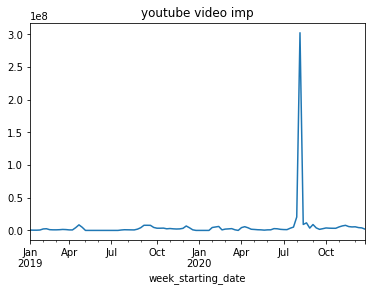

In [7]:
# Plots impressions using a time series line chart
# the plot may take a few seconds to render
df_outlier.groupby('week_starting_date')['youtube_video_imp'].sum().plot(title='youtube video imp')

## Detect and Adjust Impressions data that can be deemed an outlier

In [8]:
# Uses the mean and standard deviation of the impressions data to find the greatest value that is not an outlier 
var_mean = df_outlier.loc[df_outlier['youtube_video_imp']>0]['youtube_video_imp'].mean()

var_std = df_outlier.loc[df_outlier['youtube_video_imp']>0]['youtube_video_imp'].std()

high_outlier = var_mean + (2 * var_std)
print(high_outlier)

71281124.8598304


In [9]:
# Pulls the subset of the data that has an outlier in the amount of impressions
df_outlier[df_outlier['youtube_video_imp'] > high_outlier]

,week_starting_date,youtube_video_imp
83,2020-08-10,302536138.3


In [10]:
#  For the data identified as an outlier, replaced the impressions value with the 95 percentile value of the dataset excluding outliers
df_outlier['youtube_video_imp'] = np.where(df_outlier['youtube_video_imp'] > high_outlier,
                                           np.quantile(df_outlier[df_outlier['youtube_video_imp']< high_outlier]['youtube_video_imp'], .95),
                                           df_outlier['youtube_video_imp'])

In [11]:
# Sets the index of the dataframe as week_starting_date to set up for time series plot
df_outlier = df_outlier.set_index('week_starting_date')

## Plot impressions with outliers adjusted

<AxesSubplot:title={'center':'youtube video imp'}, xlabel='week_starting_date'>

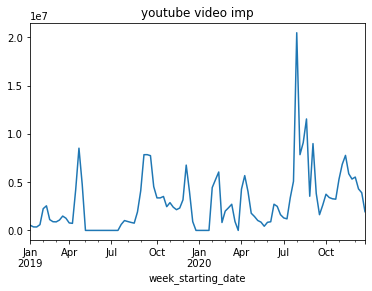

In [19]:
# the plot may take a few seconds to render
# Write the code that plots the adjusted impressions - HINT: Leverage other plotting code in this script
df_outlier.groupby('week_starting_date')['youtube_video_imp'].sum().plot(title='youtube video imp')

## Export processed data

In [18]:
# Export the final processed dataframe into a csv file
df_outlier.to_csv(file_name)